# BFS

## 二维网格

<span id='P.130'></span>
### [130. 被围绕的区域](https://leetcode.cn/problems/surrounded-regions/)

<span id='P.200'></span> 
### [200. 岛屿数量](https://leetcode.cn/problems/number-of-islands/)
给你一个由`'1'`（陆地）和`'0'`（水）组成的的二维网格，请你计算网格中岛屿的数量。<br>
岛屿总是被水包围，并且每座岛屿只能由水平方向和/或竖直方向上相邻的陆地连接形成。<br>
此外，你可以假设该网格的四条边均被水包围。

**示例 2**：
> 输入：grid = [
  ["1","1","0","0","0"],
  ["1","1","0","0","0"],
  ["0","0","1","0","0"],
  ["0","0","0","1","1"]
]<br>
输出：3

In [1]:
#include <iostream>
#include <vector>

int numIslands(std::vector<std::vector<char>>& grid) {
    int count = 0;
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == '1') {
                count += 1;
                std::vector<std::vector<int>> record;
                std::vector<int> coordinate = {ii, jj};
                record.emplace_back(coordinate);
                while (record.size() > 0) {
                    std::vector<std::vector<int>> record_new;
                    for (auto coor : record) {
                        int xx = coor[0];
                        int yy = coor[1];
                        if (xx > 0 && grid[xx - 1][yy] == '1') {
                            coordinate = {xx - 1, yy};
                            record_new.emplace_back(coordinate);
                            grid[xx - 1][yy] = '2';
                        }
                        if (xx + 1 < grid.size() && grid[xx + 1][yy] == '1') {
                            coordinate = {xx + 1, yy};
                            record_new.emplace_back(coordinate);
                            grid[xx + 1][yy] = '2';
                        }
                        if (yy > 0 && grid[xx][yy - 1] == '1') {
                            coordinate = {xx, yy - 1};
                            record_new.emplace_back(coordinate);
                            grid[xx][yy - 1] = '2';
                        }
                        if (yy + 1 < grid[0].size() && grid[xx][yy + 1] == '1') {
                            coordinate = {xx, yy + 1};
                            record_new.emplace_back(coordinate);
                            grid[xx][yy + 1] = '2';
                        }
                    }
                    record.swap(record_new);
                }
            }
        }
    }
    return count;
}

In [2]:
std::vector<char> row1 = {'1','1','0','0','0'};
std::vector<char> row2 = {'1','1','0','0','0'};
std::vector<char> row3 = {'0','0','1','0','0'};
std::vector<char> row4 = {'0','0','0','1','1'};
std::vector<std::vector<char>> grid;
grid.emplace_back(row1);
grid.emplace_back(row2);
grid.emplace_back(row3);
grid.emplace_back(row4);

std::cout << numIslands(grid) << std::endl;

3


<span id='P.994'></span> 
### [994. 腐烂的橘子](https://leetcode.cn/problems/rotting-oranges)
在给定的`m x n`网格`grid`中，每个单元格可以有以下三个值之一：
- 值`0`代表空单元格；
- 值`1`代表新鲜橘子；
- 值`2`代表腐烂的橘子。

每分钟，腐烂的橘子**周围 4 个方向上相邻**的新鲜橘子都会腐烂。<br>
返回*直到单元格中没有新鲜橘子为止所必须经过的最小分钟数。如果不可能，返回*`-1`。

**示例 1**：
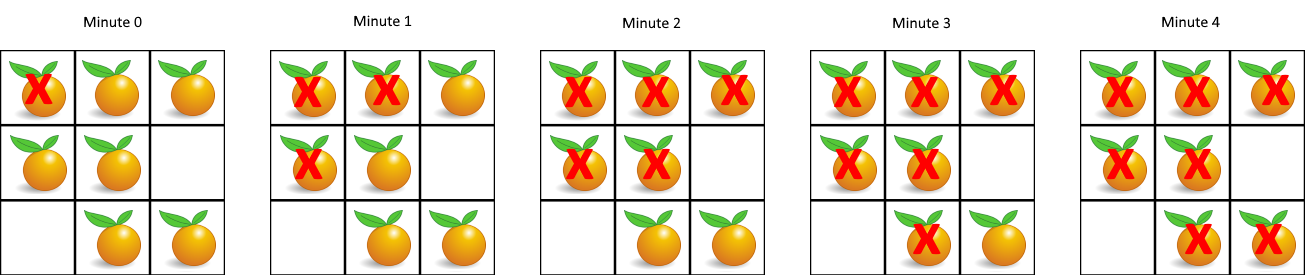
> 输入：grid = [[2,1,1],[1,1,0],[0,1,1]]<br>
> 输出：4

In [ ]:
#include <iostream>
#include <vector>

int orangesRotting(std::vector<std::vector<int>>& grid) {
    std::vector<std::vector<int>> record;
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == 2) {
                std::vector<int> coordinate = {ii, jj};
                record.emplace_back(coordinate);
            }
        }
    }
    int count = 0;
    std::vector<int> coor_next;
    while (record.size() > 0) {
        std::vector<std::vector<int>> record_new;
        for (auto coor : record) {
            int ii = coor[0];
            int jj = coor[1];
            if (ii - 1 >= 0 && grid[ii - 1][jj] == 1) {
                coor_next = {ii - 1, jj};
                grid[ii - 1][jj] = 2;
                record_new.emplace_back(coor_next);
            }
            if (ii + 1 < grid.size() && grid[ii + 1][jj] == 1) {
                coor_next = {ii + 1, jj};
                grid[ii + 1][jj] = 2;
                record_new.emplace_back(coor_next);
            }
            if (jj - 1 >= 0 && grid[ii][jj - 1] == 1) {
                coor_next = {ii, jj - 1};
                grid[ii][jj - 1] = 2;
                record_new.emplace_back(coor_next);
            }
            if (jj + 1 < grid[0].size() && grid[ii][jj + 1] == 1) {
                coor_next = {ii, jj + 1};
                grid[ii][jj + 1] = 2;
                record_new.emplace_back(coor_next);
            }
        }
        if (record_new.size() > 0) {
            count += 1;
        }
        record.swap(record_new);
    }
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == 1) {
                return -1;
            }
        }
    }
    return count;
}

In [ ]:
std::vector<int> row1 = {2,1,1};
std::vector<int> row2 = {1,1,0};
std::vector<int> row3 = {0,1,1};
std::vector<std::vector<int>> grid;
grid.emplace_back(row1);
grid.emplace_back(row2);
grid.emplace_back(row3);
std::cout << orangesRotting(grid) << std::endl;

# DFS

<span id='P.463'></span> 
## [463. 岛屿的周长](https://leetcode.cn/problems/island-perimeter/)
给定一个`row x col`的二维网格地图`grid`，其中：`grid[i][j] = 1`表示陆地，`grid[i][j] = 0`表示水域。<br>
网格中的格子**水平和垂直**方向相连（对角线方向不相连）。整个网格被水完全包围，但其中恰好有一个岛屿（或者说，一个或多个表示陆地的格子相连组成的岛屿）。<br>
岛屿中没有“湖”（“湖” 指水域在岛屿内部且不和岛屿周围的水相连）。格子是边长为 1 的正方形。网格为长方形，且宽度和高度均不超过 100 。计算这个岛屿的周长。

**示例 1**：
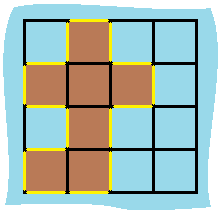
> 输入：grid = [[0,1,0,0],[1,1,1,0],[0,1,0,0],[1,1,0,0]]<br>
输出：16<br>
解释：它的周长是上面图片中的 16 个黄色的边

> 题解:
**岛屿的周长就是岛屿方格和非岛屿方格相邻的边的数量**。注意，这里的非岛屿方格，既包括**水域方格**，也包括**网格边界**，如下图所示：
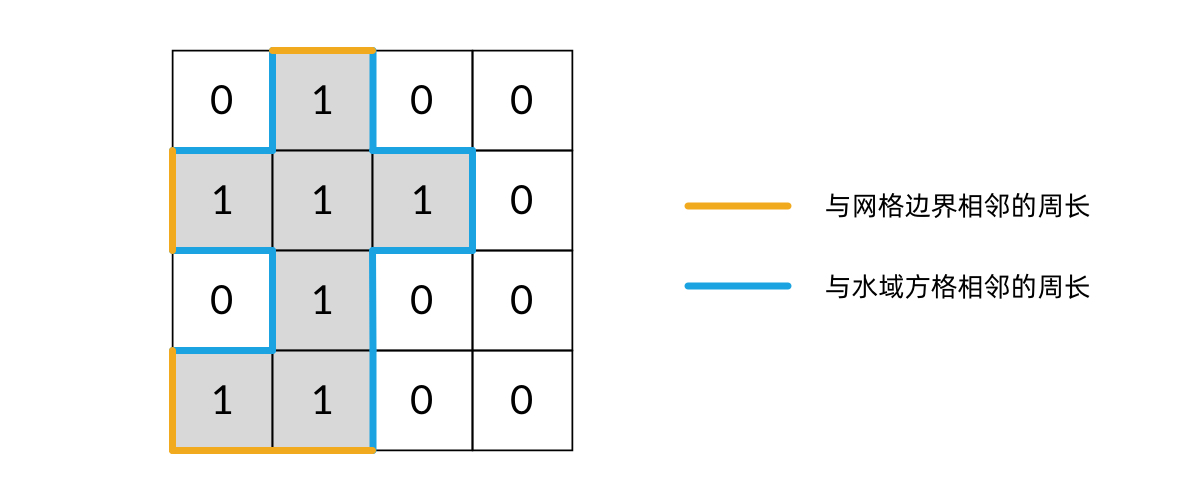

In [ ]:
#include <iostream>
#include <vector>

int Length(int ii, int jj, std::vector<std::vector<int>> &grid) { // 因为 grid 需要修改, 因此 grid 前要加 引用'&'
    if (ii < 0 || ii >= grid.size() || jj < 0 || jj >= grid[0].size() || grid[ii][jj] == 0) { // 网格边界或者水域方格
        return 1;
    }
    if (grid[ii][jj] == 2) {
        return 0;
    }
    grid[ii][jj] = 2;
    int count = 0;
    count += Length(ii + 1, jj, grid);
    count += Length(ii - 1, jj, grid);
    count += Length(ii, jj + 1, grid);
    count += Length(ii, jj - 1, grid);
    return count;
}

In [ ]:
int islandPerimeter(std::vector<std::vector<int>>& grid) {
    for (int ii = 0; ii < grid.size(); ii++) {
        for (int jj = 0; jj < grid[0].size(); jj++) {
            if (grid[ii][jj] == 1) {
                return Length(ii, jj, grid);
            }
        }
    }
    return 0;
}

In [ ]:
std::vector<std::vector<int>> grid;

// std::vector<int> row = {1, 1};
// grid.emplace_back(row);
// grid.emplace_back(row);

std::vector<int> row1 = {0,1,0,0};
std::vector<int> row2 = {1,1,1,0};
std::vector<int> row3 = {0,1,0,0};
std::vector<int> row4 = {1,1,0,0};
grid.emplace_back(row1);
grid.emplace_back(row2);
grid.emplace_back(row3);
grid.emplace_back(row4);

std::cout << islandPerimeter(grid) << std::endl;

# todo
https://zhuanlan.zhihu.com/p/656641191